# RNA-TDA Pathogenicity: 端到端演示

本 Notebook 演示 ncRNA 变异致病性预测的完整流程：
1. **结构建模**：ViennaRNA 提取碱基配对概率（BPP）
2. **拓扑分析**：Ripser 持久同调提取结构稳定性指纹
3. **知识检索**：ChromaDB 检索 ClinVar 历史记录
4. **融合预测**：轻量 Transformer 输出致病性概率

---

In [16]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

# 检查核心依赖
import RNA
import numpy as np
from ripser import ripser
import torch

print(f"ViennaRNA: OK")
print(f"Ripser: OK")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {torch.device('cpu')}")

ViennaRNA: OK
Ripser: OK
PyTorch: 2.12.1+cpu
Device: cpu


## 1. 结构建模：ViennaRNA BPP 提取

输入 RNA 序列，输出碱基配对概率矩阵（BPP）和 MFE 结构。

In [17]:
from src.pipeline import RNAStructureModeler

modeler = RNAStructureModeler()
sequence = "GGGAAACCC"

# BPP 矩阵
bpp = modeler.get_bpp_matrix(sequence)

# MFE 结构
mfe_struct, mfe_energy = modeler.get_mfe(sequence)

print(f"序列: {sequence}")
print(f"MFE 结构: {mfe_struct}")
print(f"MFE 能量: {mfe_energy:.2f} kcal/mol")
print(f"BPP 矩阵大小: {bpp.shape}")

# 打印强配对 (>0.5)
n = len(sequence)
for i in range(n):
    for j in range(i+1, n):
        if bpp[i,j] > 0.5:
            print(f"  {i+1}({sequence[i]}) - {j+1}({sequence[j]}): {bpp[i,j]:.3f}")

序列: GGGAAACCC
MFE 结构: (((...)))
MFE 能量: -1.20 kcal/mol
BPP 矩阵大小: (9, 9)
  1(G) - 9(C): 0.524
  2(G) - 8(C): 0.536
  3(G) - 7(C): 0.519


## 2. 拓扑分析：Ripser 持久同调

将 BPP 矩阵转换为距离矩阵，计算 0 维/1 维持久同调，提取结构稳定性指纹。

In [18]:
from src.pipeline import RNATopologicalFingerprint

tda = RNATopologicalFingerprint()
features = tda.extract(bpp)

print("拓扑特征:")
for k, v in features.items():
    if k != "vector":
        print(f"  {k}: {v}")

print(f"\n特征向量 (8维): {features['vector']}")

拓扑特征:
  betti0_count: 0
  mean_persist_0: 0.0
  max_persist_0: 0.0
  betti1_count: 3
  mean_persist_1: 0.2809324463208516
  max_persist_1: 0.5358507931232452
  std_persist_1: 0.18027703514094628

特征向量 (8维): [0.         0.         0.         3.         0.28093246 0.53585076
 0.18027703 0.09      ]


### 持久图可视化

1 维持久图上的点离对角线越远，代表结构越稳定。

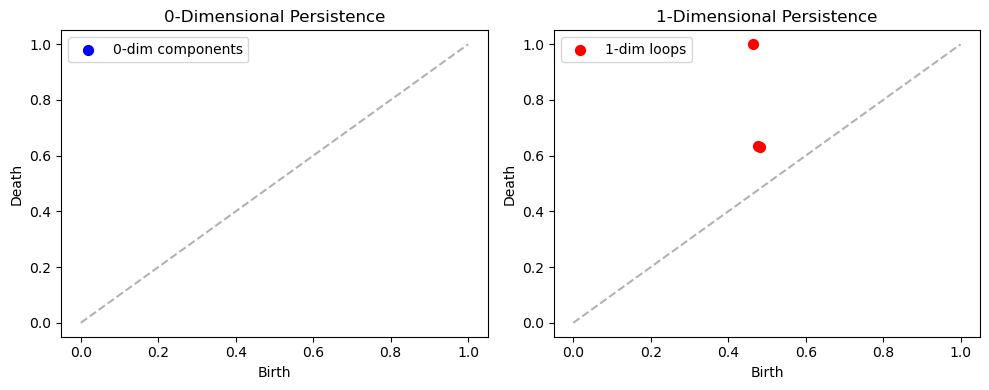

In [19]:
import matplotlib.pyplot as plt
from ripser import ripser

dist = tda.bpp_to_distance(bpp)
result = ripser(dist, distance_matrix=True, maxdim=1)
dgms = result['dgms']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# 0 维
dgm0 = dgms[0]
finite0 = dgm0[dgm0[:, 1] != np.inf]
axes[0].scatter(finite0[:, 0], finite0[:, 1], s=50, c='blue', label='0-dim components')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('Birth')
axes[0].set_ylabel('Death')
axes[0].set_title('0-Dimensional Persistence')
axes[0].legend()

# 1 维
dgm1 = dgms[1]
if len(dgm1) > 0:
    axes[1].scatter(dgm1[:, 0], dgm1[:, 1], s=50, c='red', label='1-dim loops')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('Birth')
axes[1].set_ylabel('Death')
axes[1].set_title('1-Dimensional Persistence')
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. 知识库验证：ChromaDB + ClinVar

验证知识库中的 ncRNA 致病变异记录。

In [ ]:
from src.rag.knowledge_base import BirthDefectRAG

rag = BirthDefectRAG(db_path="../chroma_db")

# 1. 先看一眼总量
total = rag.collection.count()
print(f"知识库总记录数: {total}")

# 2. 真正的 RAG 检索：输入查询文本，找语义相似记录
print("\n" + "="*60)
print("【RAG 语义检索】查询：RNA sequence GGGAAACCC variant at position 0")
print("="*60)

query = "RNA sequence GGGAAACCC variant at position 0"
results = rag.retrieve(query, n_results=3)

for i, (doc_id, doc_text, meta) in enumerate(zip(
    results['ids'][0], 
    results['documents'][0], 
    results['metadatas'][0]
), 1):
    print(f"\n--- 相似记录 {i} ---")
    print(f"ID: {doc_id}")
    print(f"基因: {meta.get('gene', 'N/A')}")
    print(f"疾病: {meta.get('disease', 'N/A')}")
    print(f"临床意义: {meta.get('clinical_significance', 'N/A')}")
    print(f"文本: {doc_text[:150]}...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2197.02it/s]


知识库总记录数: 297

【RAG 语义检索】查询：RNA sequence GGGAAACCC variant at position 0

--- 相似记录 1 ---
ID: clinvar_2632624
基因: SNHG14
疾病: UBE3A-related_disorder
临床意义: Likely_pathogenic
文本: ClinVar variation 2632624; Gene: SNHG14; Variant: NC_000015.10:g.25375536G>T; Clinical significance: Likely_pathogenic; Disease: UBE3A-related_disorde...

--- 相似记录 2 ---
ID: clinvar_589644
基因: SNHG14
疾病: Inborn_genetic_diseases
临床意义: Likely_pathogenic
文本: ClinVar variation 589644; Gene: SNHG14; Variant: NC_000015.10:g.25370718T>C; Clinical significance: Likely_pathogenic; Disease: Inborn_genetic_disease...

--- 相似记录 3 ---
ID: clinvar_287274
基因: SNHG14
疾病: not_provided
临床意义: Pathogenic
文本: ClinVar variation 287274; Gene: SNHG14; Variant: NC_000015.10:g.25370937C>A; Clinical significance: Pathogenic; Disease: not_provided; Molecular conse...


## 4. 端到端预测：完整 Pipeline

输入野生型序列 + 变异位点，输出致病性概率、结构变化指标、RAG 证据链。

In [21]:
from src.pipeline import RNAPathogenicityPipeline

# 初始化 Pipeline（使用训练好的模型）
pipeline = RNAPathogenicityPipeline(
    db_path="../chroma_db",
    model_path="../checkpoints/best_model.pt",
    device="cpu"
)

# 预测一个变异
result = pipeline.predict(
    wild_seq="GGGAAACCC",
    variant_pos=0,    # 茎区的 G（位置 0）
    variant_nt="A"   # G→A，破坏 G-C 配对
)

print("=" * 60)
print("预测结果")
print("=" * 60)
print(f"野生型: {result['wild_type']['sequence']}")
print(f"突变型: {result['mutant']['sequence']}")
print(f"MFE 结构: {result['mutant']['mfe_structure']}")
print(f"MFE 能量: {result['mutant']['mfe_energy']:.2f}")
print()
print(f"致病性概率: {result['pathogenicity_prob']:.4f}")
print(f"预测结果:   {'致病' if result['is_pathogenic'] else '良性'}")
print()
print("结构变化:")
for k, v in result['structural_change'].items():
    print(f"  {k}: {v:.4f}")
print()
print("RAG 证据 (Top 3):")
docs = result['evidence'].get('documents', [[]])[0]
for i, doc in enumerate(docs[:3], 1):
    print(f"  [{i}] {doc[:120]}...")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2923.14it/s]


[Model] Parameters: 842.2K
[Pipeline] 加载模型: ../checkpoints/best_model.pt
预测结果
野生型: GGGAAACCC
突变型: AGGAAACCC
MFE 结构: .........
MFE 能量: 0.00

致病性概率: 0.7127
预测结果:   致病

结构变化:
  mfe_energy_delta: 1.2000
  betti1_count_delta: -1.0000
  mean_persist_1_delta: -0.0956
  max_persist_1_delta: -0.2950

RAG 证据 (Top 3):
  [1] ClinVar variation 2632624; Gene: SNHG14; Variant: NC_000015.10:g.25375536G>T; Clinical significance: Likely_pathogenic; ...
  [2] ClinVar variation 589644; Gene: SNHG14; Variant: NC_000015.10:g.25370718T>C; Clinical significance: Likely_pathogenic; D...
  [3] ClinVar variation 287274; Gene: SNHG14; Variant: NC_000015.10:g.25370937C>A; Clinical significance: Pathogenic; Disease:...


## 5. 对比实验：野生型 vs 突变型结构变化

可视化突变导致的拓扑指纹变化。

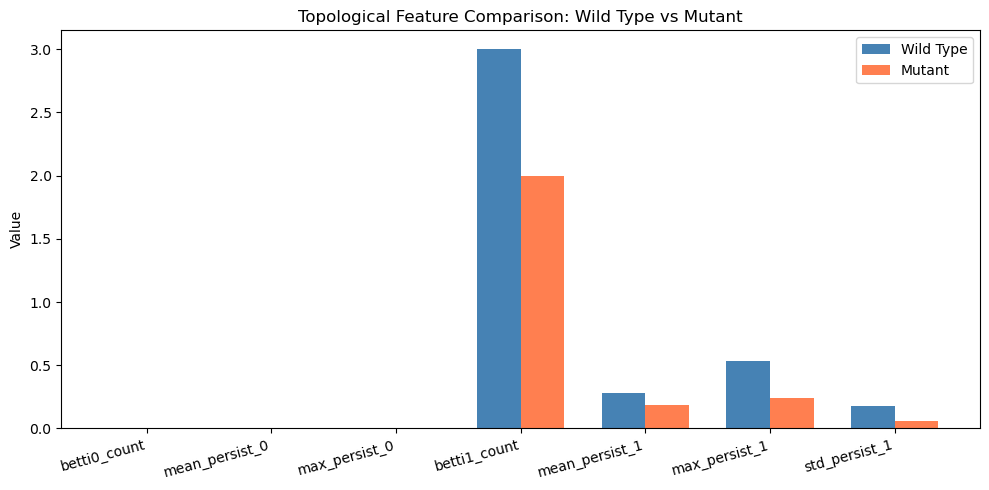

In [22]:
# 重新计算野生型特征
wild_bpp = modeler.get_bpp_matrix(result['wild_type']['sequence'])
wild_topo = tda.extract(wild_bpp)
mut_topo = tda.extract(modeler.get_bpp_matrix(result['mutant']['sequence']))

labels = ['betti0_count', 'mean_persist_0', 'max_persist_0', 
          'betti1_count', 'mean_persist_1', 'max_persist_1', 'std_persist_1']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, wild_topo['vector'][:-1], width, label='Wild Type', color='steelblue')
bars2 = ax.bar(x + width/2, mut_topo['vector'][:-1], width, label='Mutant', color='coral')

ax.set_ylabel('Value')
ax.set_title('Topological Feature Comparison: Wild Type vs Mutant')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

## 总结

本 Notebook 演示了 RNA-TDA Pathogenicity 系统的核心流程：

1. **ViennaRNA** 计算碱基配对概率矩阵（BPP）
2. **Ripser** 将 BPP 转化为拓扑指纹（持久同调）
3. **ChromaDB** 存储并检索 ClinVar ncRNA 致病变异记录
4. **轻量 Transformer** 融合序列语义与拓扑特征，输出致病性概率

### 当前局限
- 真实 ncRNA 致病变异的结构-功能对应数据稀缺
- 模拟数据基于结构稳定性代理标签，存在生物学简化
- 未来可接入 SHAPE-MaP 等真实结构探测数据提升性能

### 项目定位
概念验证系统，验证 **TDA + 轻量 AI + RAG** 在 ncRNA 变异解读中的技术可行性。